In [1]:
import xarray as xr
import numpy as np

import argparse
from os.path import join, exists
from os import makedirs
import pickle

from sklearn.neighbors import BallTree
import xesmf as xe

import matplotlib.pyplot as plt

In [2]:
meta_ds = xr.open_dataset("/glade/work/dkimpara/goes-cloud-data/goes_e_abi_full_disk_latlon_lza.nc")

# get x/y bounds for given min/max lat/lon


In [3]:
lat_width=50.1
lon_width=46.1
lon_center=-75

# optional method to subset the raw GOES by x and y bounds.

Could also just set x_bounds/y_bounds = (0, len(array))
see `process_L1b` method in download script for details

In [4]:
def get_bounds_xy(ds, lat_width=50.1, lon_width=46.1, lon_center=-75,
                  max_lza = 72.1):
    ds = ds.where(meta_ds.LZA <= max_lza)

    lat_width += 0.5
    lon_width += 0.5
    
    nonzeros = np.nonzero((ds.latitude <= lat_width) & (ds.latitude >= -lat_width))
    y_bounds = nonzeros[0].min().values, nonzeros[0].max().values

    nonzeros = np.nonzero((ds.longitude <= lon_center + lon_width) 
                          & (ds.longitude >= lon_center - lon_width))
    x_bounds = nonzeros[1].min().values, nonzeros[1].max().values

    return x_bounds, y_bounds

x_bounds, y_bounds = get_bounds_xy(meta_ds)
print(x_bounds, y_bounds)

(array(533), array(4890)) (array(426), array(4997))


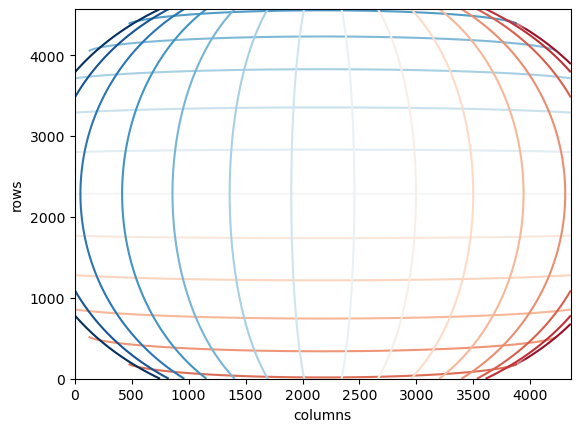

In [5]:
ds = meta_ds.sel(rows=slice(*y_bounds), columns=slice(*x_bounds))
ds.latitude.plot.contour(levels=np.arange(-90, 91, 10))
ds.longitude.plot.contour(levels=np.arange(-140, 11, 10))

# generate a target lat/lon grid


In [6]:
resolution = 0.1
half_res = resolution / 2
ds_outgrid = xe.util.cf_grid_2d(lon_center - lon_width - half_res, lon_center + lon_width + half_res, resolution,
                            -lat_width - half_res, lat_width + half_res, resolution)
ds_outgrid

<xarray.Dataset> Size: 46kB
Dimensions:             (lon: 923, bound: 2, lat: 1003)
Coordinates:
  * lon                 (lon) float64 7kB -121.1 -121.0 -120.9 ... -29.0 -28.9
  * lat                 (lat) float64 8kB -50.1 -50.0 -49.9 ... 49.9 50.0 50.1
    latitude_longitude  float64 8B nan
Dimensions without coordinates: bound
Data variables:
    lon_bounds          (lon, bound) float64 15kB -121.1 -121.0 ... -28.85
    lat_bounds          (lat, bound) float64 16kB -50.15 -50.05 ... 50.05 50.15

# generate balltree from source latlon coords

In [7]:
lon_grid, lat_grid = ds.longitude, ds.latitude

lon_flat = lon_grid.values.ravel()
lat_flat = lat_grid.values.ravel()
print("Size:", lon_flat.size)

not_nan_indices = np.argwhere(~np.isnan(lon_flat)).ravel()

lat_lon = np.stack([lat_flat, lon_flat], axis=-1)
rad_lat_lon = np.deg2rad(lat_lon)[not_nan_indices]




Size: 19915847


In [8]:
tree = BallTree(rad_lat_lon, metric="haversine")

In [9]:
km_spacing = np.deg2rad(0.1) * 6371
print(km_spacing / 2)

5.559746332227937


In [10]:
radius_km = 5.9
radius_rad = radius_km / 6371

In [11]:
target_lon, target_lat = ds_outgrid.lon.values, ds_outgrid.lat.values

lon_grid, lat_grid = np.meshgrid(target_lon, target_lat)

lon_flat = lon_grid.ravel()
lat_flat = lat_grid.ravel()

print("Size:", lon_flat.size)

print(target_lon.shape)
print(lon_grid.shape)
print(lat_grid.shape)

lat_lon = np.stack([lat_flat, lon_flat], axis=-1)
target_rad_lat_lon = np.deg2rad(lat_lon)


neighbors = tree.query_radius(target_rad_lat_lon, r=radius_rad,
                                      return_distance=False,)

Size: 925769
(923,)
(1003, 923)
(1003, 923)


In [12]:
# check for empty neighbor sets

for i, indices in enumerate(neighbors):
    if len(indices) == 0:
        print(i, lat_lon[i])

# look at source point spacing

In [13]:
target_deg = np.rad2deg(target_rad_lat_lon)
def visualize(index, marker=None):
    lat_lon = np.rad2deg(rad_lat_lon[neighbors[index]])
    plt.scatter(lat_lon[:, 1], lat_lon[:, 0], marker=marker)
    plt.scatter(target_deg[index][1], target_deg[index][0], c="0")


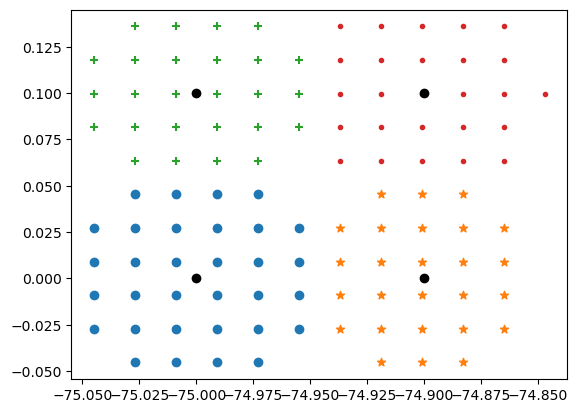

In [14]:
lat, lon = 0, -75

index = np.argwhere(np.isclose(target_deg[:, 0], lat) & np.isclose(target_deg[:, 1], lon)).flatten()[0]

visualize(index)
visualize(index+1, marker="*")

lat, lon = 0.1, -75

index = np.argwhere(np.isclose(target_deg[:, 0], lat) & np.isclose(target_deg[:, 1], lon)).flatten()[0]

visualize(index, marker="+")
visualize(index+1, marker=".")

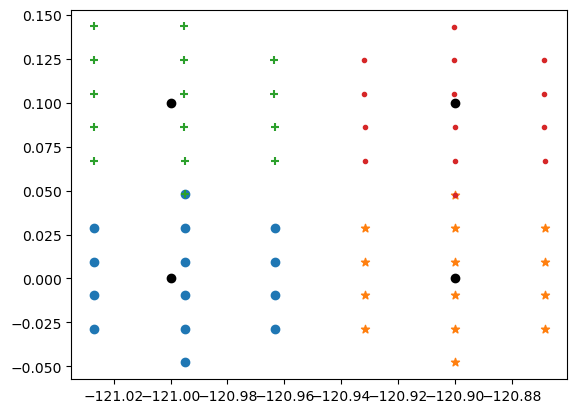

In [15]:
lat, lon = 0, -121

index = np.argwhere(np.isclose(target_deg[:, 0], lat) & np.isclose(target_deg[:, 1], lon)).flatten()[0]

visualize(index)
visualize(index+1, marker="*")

lat, lon = 0.1, -121

index = np.argwhere(np.isclose(target_deg[:, 0], lat) & np.isclose(target_deg[:, 1], lon)).flatten()[0]

visualize(index, marker="+")
visualize(index+1, marker=".")

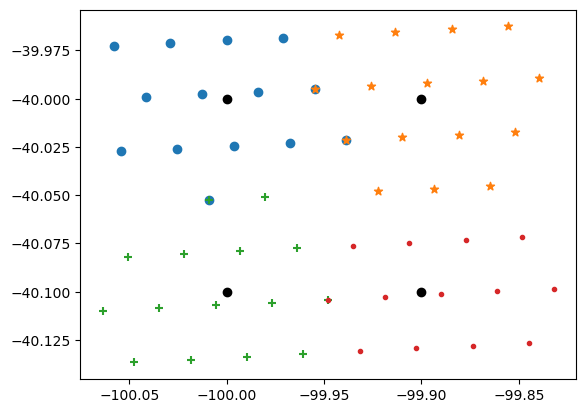

In [16]:

lat, lon = -40, -100

index = np.argwhere(np.isclose(target_deg[:, 0], lat) & np.isclose(target_deg[:, 1], lon)).flatten()[0]

visualize(index)
visualize(index+1, marker="*")

lat, lon = -40.1, -100

index = np.argwhere(np.isclose(target_deg[:, 0], lat) & np.isclose(target_deg[:, 1], lon)).flatten()[0]

visualize(index, marker="+")
visualize(index+1, marker=".")

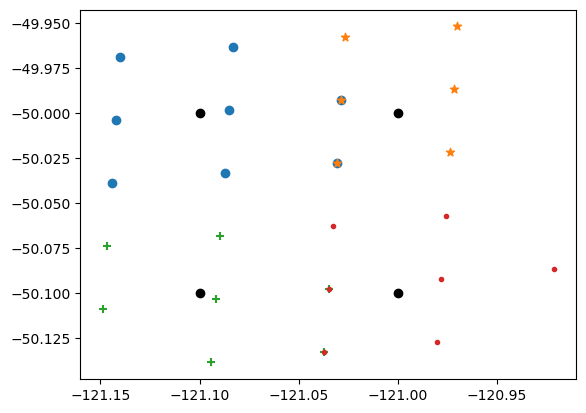

In [17]:

lat, lon = -50, -121.1

index = np.argwhere(np.isclose(target_deg[:, 0], lat) & np.isclose(target_deg[:, 1], lon)).flatten()[0]

visualize(index)
visualize(index+1, marker="*")

lat, lon = -50.1, -121.1

index = np.argwhere(np.isclose(target_deg[:, 0], lat) & np.isclose(target_deg[:, 1], lon)).flatten()[0]

visualize(index, marker="+")
visualize(index+1, marker=".")

# check order

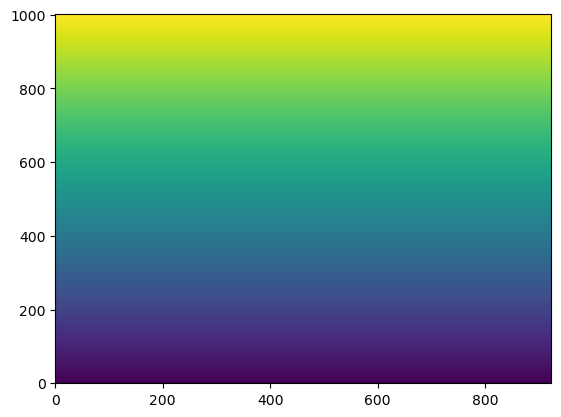

In [18]:
num_lat, num_lon = len(ds_outgrid.lat), len(ds_outgrid.lon)

latlons = np.deg2rad(target_rad_lat_lon)
lat = latlons[:,0].reshape(num_lat, num_lon)
plt.pcolormesh(lat)

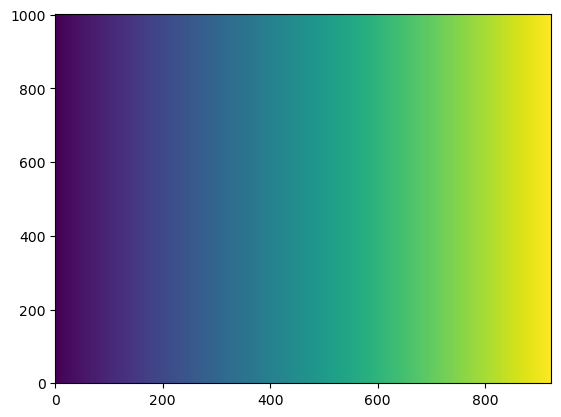

In [19]:
lon = latlons[:,1].reshape(num_lat, num_lon)
plt.pcolormesh(lon)

# time a computation

In [20]:
%%time

means = np.empty((len(neighbors), 2))

for i, indices in enumerate(neighbors):
    avg = np.mean(rad_lat_lon[indices], axis=0)
    means[i] = avg
    

CPU times: user 5.18 s, sys: 42.9 ms, total: 5.23 s
Wall time: 5.19 s


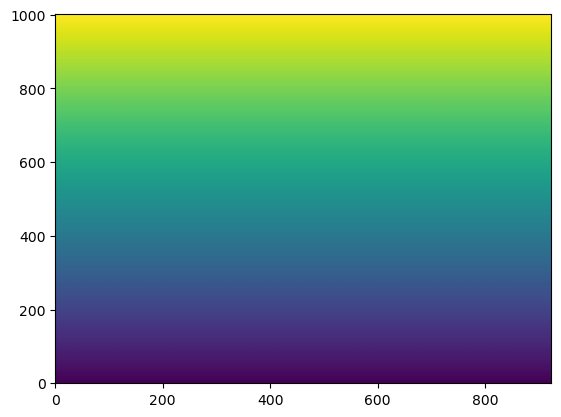

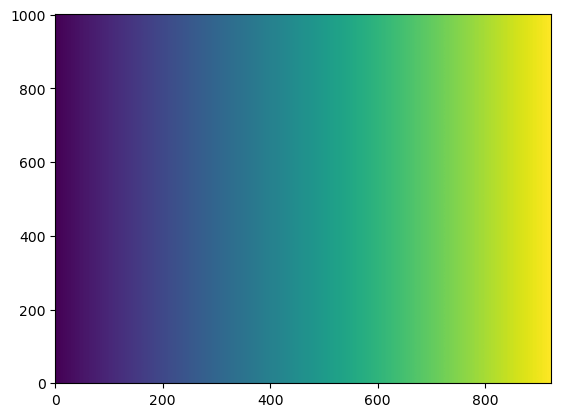

In [21]:
lat_avg = means[:,0].reshape(num_lat, num_lon)
plt.pcolormesh(lat_avg)
plt.show()

lon_avg = means[:,1].reshape(num_lat, num_lon)
plt.pcolormesh(lon_avg)
plt.show()

In [22]:
import pandas as pd
import pickle

# save regrid lookup dict to pickle file

In [24]:
griddata_loc = "/glade/work/dkimpara/goes-cloud-data/6km_regrid_data.pkl"

regrid_data_dict = {
    "x_bounds": x_bounds,
    "y_bounds": y_bounds,
    "neighbors": neighbors,
    "not_nan_indices": not_nan_indices,
}
# with open(griddata_loc, 'wb') as f:
#     pickle.dump(regrid_data_dict, f)

In [25]:
ds_outgrid.to_netcdf("/glade/work/dkimpara/goes-cloud-data/0_1deg_grid.nc")

In [26]:
ds_out2 = xr.open_dataset("/glade/work/dkimpara/goes-cloud-data/0_1deg_grid.nc")
ds_out2

<xarray.Dataset> Size: 46kB
Dimensions:             (lon: 923, bound: 2, lat: 1003)
Coordinates:
  * lon                 (lon) float64 7kB -121.1 -121.0 -120.9 ... -29.0 -28.9
  * lat                 (lat) float64 8kB -50.1 -50.0 -49.9 ... 49.9 50.0 50.1
    latitude_longitude  float64 8B ...
Dimensions without coordinates: bound
Data variables:
    lon_bounds          (lon, bound) float64 15kB ...
    lat_bounds          (lat, bound) float64 16kB ...